In [102]:
import sys
import os

sys.path.append(os.path.abspath('./predictability_emergence')) 

import DataMakar
import DataHolder
import buildmodel
import helpers

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

import torch.optim.lr_scheduler as lr_scheduler
import time

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import glob
import json
import pickle

import cartopy.crs as ccrs
import matplotlib as mpl

mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.size'] = 12
mpl.rcParams['font.sans-serif']=['Verdana']

params = {"ytick.color": "k",
          "xtick.color": "k",
          "axes.labelcolor": "k",
          "axes.edgecolor": "k"}
plt.rcParams.update(params)

# import imageio

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_curve


### Set the experiment parameters to grab the data with the correct formatting

In [103]:
ssplist = ["126","245","370","585"]

# set user parameters

experiment_era = [1950,2100]
baselineera = [1900,1950]
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

inputlength = 10
outputavgtime = 5

# data params
outres = 10
timerange = [1900,2100]
filefront = "MPI_"
modelfilefront = "MPI_recordtemp_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'

data_dir = 'data'

seedlist = [62469869,
            71856281,
            47621498,
            10431957,
            50561320,
            72166634,
            18469465,
            92895735,
            57693846,
            22284750]



### Grab the data

In [104]:
imp.reload(DataHolder)

params = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
    "data_dir":data_dir,
}

ntrain = 25
nval = 13
test = np.arange(38,50)


#get the data

AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)

latvec = AllData.output_lat
lonvec = AllData.output_lon

data/MPI_annualmean_126_tos_1900-2100.pkl
data/MPI_annualmean_245_tos_1900-2100.pkl
data/MPI_annualmean_370_tos_1900-2100.pkl
data/MPI_annualmean_585_tos_1900-2100.pkl


In [105]:
alltrain,allval,alltest = AllData.trainvaltest_histrecordmax(trainvaltest,experiment_era,baselineera,inputlength,5,40,240)

baseline for temp records is 0 50 (not used)
indices of future period are 104 -4
working on 126
working on 245
working on 370
working on 585


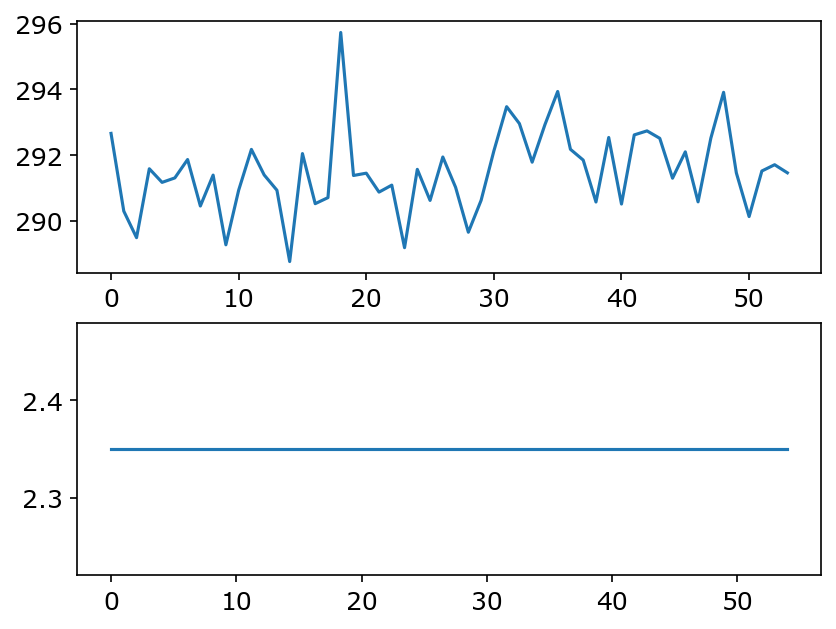

In [106]:
plt.subplot(2,1,1,)
plt.plot(AllData.alloutput[0][38,60:114,13,25])
plt.subplot(2,1,2)
plt.plot(alltest[2][:55])



In [107]:
np.mean(alltrain[-1].squeeze())

0.8014016172506738

In [108]:
np.max(AllData.alloutput[0][38,60:114,13,25])-np.mean(AllData.alloutput[0][38,60:90,13,25])

4.657383724111924

### Some useful functions

In [109]:
def confacc(predclass,trueclass,predconf):

    predcorr = predclass==trueclass
    percentiles = np.arange(0,100,5)
    accper = np.empty(20)
    for iper,per in enumerate(percentiles):

        perboo = np.percentile(predconf,per)
        accper[iper] = np.mean(predcorr[predconf>perboo])

    return accper

def firstpositive(pred,gmtvec):
    if np.sum(pred[pred>0.5])>1:
        firstpos = np.min(gmtvec[pred>0.5])
    else:
        firstpos = np.nan
    return firstpos

def firstconfident(pred,gmtvec):

    conf = np.where(pred<0.5,1-pred,pred)
    percentile = np.percentile(conf,50)
    if np.sum(1*((pred>0.5) & (conf>percentile)))>0:
        firstconf = np.min(gmtvec[(pred>0.5) & (conf>percentile)])
    else:
        firstconf = np.nan
    return firstconf

def firstcorrect(pred,true,gmtvec):
    predclass = np.round(pred)
    if np.sum((predclass==1) & (true==1))>0:
        firstcorrect = np.min(gmtvec[(predclass==1) & (true==1)])
    else:
        firstcorrect = np.nan
    return firstcorrect
    
def grabssp(data,issp,lenhist,lenfuture,nmems):

    if issp == 0:
        dataout = data[:nmems*lenhist,]
    else:
        dataout = data[nmems*(lenhist+(issp-1)*lenfuture):nmems*(lenhist+(issp)*lenfuture),]
    
    return dataout

def binnedprobs(data,gmt,gmtbins):

    binwidth = gmtbins[1]-gmtbins[0] 
    binneddata = np.empty((len(gmtbins[:-1])))+np.nan
    for ibin,lbin in enumerate(gmtbins[:-1]):
        if len(data[(gmt>lbin) & (gmt<=(lbin+binwidth))])>1:
            binneddata[ibin] = np.mean(data[(gmt>lbin) & (gmt<=(lbin+binwidth))])
        else:
            binneddata[ibin] = np.nan

    return binneddata,gmtbins[:-1]+binwidth

### Select an example point 

ilatsel corresponds to the index of the latitude. Convert to lat coordinate by lat = (ilatsel-9) $\times$ 10 (only for outres=10)

ilonsel corresponds to the index of the longitude. Convert to lon coorditate by lon = (ilonsel) $\times$ 10 

In [152]:
ilatsel = 4
ilonsel = 17

latsel = latvec[ilatsel]
lonsel = lonvec[ilonsel]

In [153]:
trainvaltest = [np.arange(25),np.arange(25,38),test]

alltrain, allval, alltest = AllData.trainvaltest_recordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,latsel,lonsel)

inputtrain, inputtrainGMT,outputtrainall = DataHolder.tensortime_onehot(alltrain,nclasses=2)
inputtest, inputtestGMT, outputtest = DataHolder.tensortime_onehot(alltest,nclasses=2)

outputtrain = np.argmax(outputtrainall.numpy(),axis=1)
outputtest = np.argmax(outputtest.numpy(),axis=1)

inputssptrain,inputsspval,inputssptest = AllData.trainvaltest_recordmax_ssps(trainvaltest,experiment_era,inputlength,outputavgtime,latsel)

inputssptrain = np.round((inputssptrain.squeeze()+0.2)*10)
inputssptest = np.round((inputssptest.squeeze()+0.2)*10)

baseline for temp records is 0 50
indices of future period are 104 -4
working on 126
working on 245
working on 370
working on 585
indices of future period are 104 -4
working on 126
working on 245
working on 370
working on 585


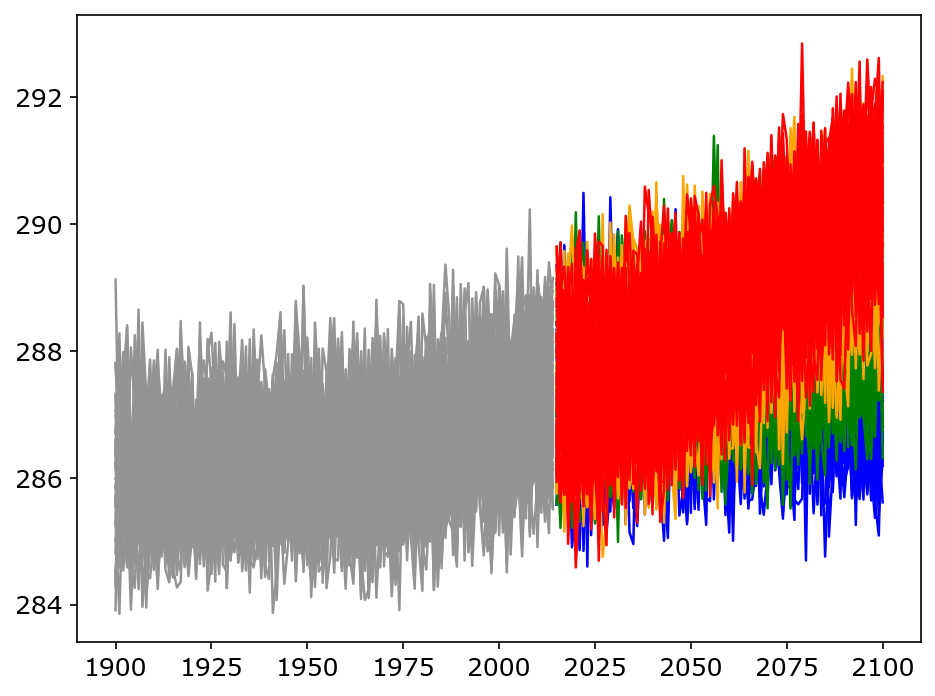

In [154]:
sspcols = ['blue','green','orange','red']

for issp in range(4):

    summersel = AllData.alloutput[issp][:,:,ilatsel,ilonsel]

    if issp == 0:

        plt.plot(np.arange(timerange[0],2015),np.transpose(summersel[:,:115]),color='xkcd:grey',linewidth=1.2)
    
    plt.plot(np.arange(2015,timerange[-1]+1),np.transpose(summersel[:,115:]),color=sspcols[issp],label=ssplist[issp],linewidth=1.2)

plt.tight_layout()
plt.show()



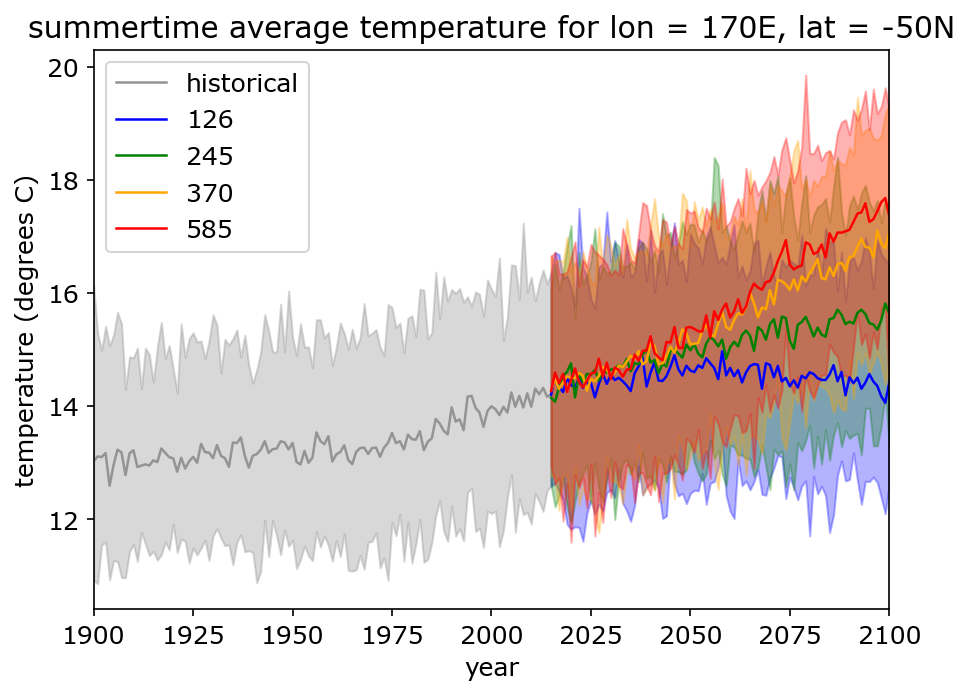

In [155]:
sspcols = ['blue','green','orange','red']

for issp in range(4):

    summersel = AllData.alloutput[issp][:,:,ilatsel,ilonsel]-273

    if issp == 0:

        plt.plot(np.arange(timerange[0],2016),np.mean(summersel[:,:116],axis=0),color='xkcd:grey',linewidth=1.2,label='historical')
        plt.fill_between(np.arange(timerange[0],2016),np.min(summersel[:,:116],axis=0),np.max(summersel[:,:116],axis=0),color='grey',alpha=0.3)
    
    plt.plot(np.arange(2015,timerange[-1]+1),np.mean(summersel[:,115:],axis=0),color=sspcols[issp],linewidth=1.2,label=ssplist[issp])
    plt.fill_between(np.arange(2015,timerange[-1]+1),np.min(summersel[:,115:],axis=0),np.max(summersel[:,115:],axis=0),color=sspcols[issp],alpha=0.3)

plt.title('summertime average temperature for lon = ' + str(lonsel)+'E, lat = '+ str(latsel)+ 'N' )
plt.ylabel('temperature (degrees C)')
plt.xlabel('year')
plt.xlim(1900,2100)
plt.legend()

plt.tight_layout()
plt.show()

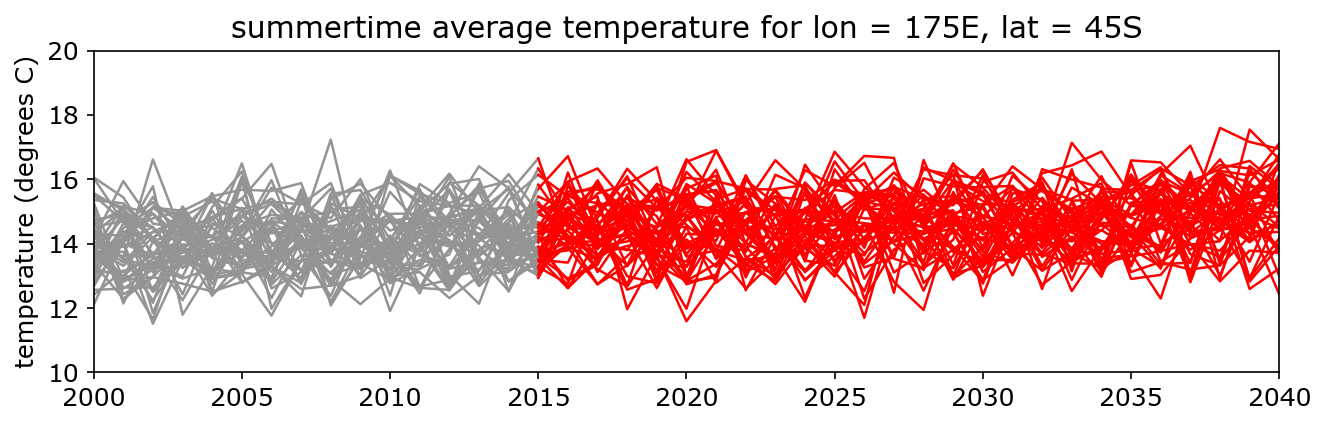

In [189]:
sspcols = ['blue','green','orange','red']

# for issp in range(4):

ilatsel = 4
ilonsel = 17

summersel = AllData.alloutput[3][:,:,ilatsel,ilonsel]-273

maxes = np.zeros(summersel.shape)

for i in range(summersel.shape[0]):
    currentmax = np.max(summersel[i,0:50])
    # print(currentmax)
    for j in range(summersel.shape[1]-50):
        maxcheck = summersel[i,j+50]>currentmax
        if maxcheck:
            maxes[i,j+50] = 1.
            currentmax = summersel[i,j+50]

maxes[maxes==0] = np.nan

plt.figure(figsize=(9,3))

# plt.plot(np.arange(timerange[0],2016),summersel[0,:116],color='xkcd:grey',linewidth=1.2,label='hist')
# plt.scatter(np.arange(timerange[0],2016),maxes[0,:116]*summersel[0,:116],color='xkcd:maroon')

# plt.plot(np.arange(2015,timerange[-1]+1),summersel[0,115:],color=sspcols[3],label=ssplist[issp],linewidth=1.2)
# plt.scatter(np.arange(2015,timerange[-1]+1),maxes[0,115:]*summersel[0,115:],color='xkcd:maroon')

# plt.plot(np.arange(timerange[0],2016),summersel[1,:116],color='xkcd:grey',linewidth=1.2)
# plt.scatter(np.arange(timerange[0],2016),maxes[1,:116]*summersel[1,:116],color='xkcd:maroon')

# plt.plot(np.arange(2015,timerange[-1]+1),summersel[1,115:],color=sspcols[3],linewidth=1.2)
# plt.scatter(np.arange(2015,timerange[-1]+1),maxes[1,115:]*summersel[1,115:],color='xkcd:maroon')

for mem in range(50):

    plt.plot(np.arange(timerange[0],2016),summersel[mem,:116],color='xkcd:grey',linewidth=1.2)
    # plt.scatter(np.arange(timerange[0],2016),maxes[mem,:116]*summersel[mem,:116],color='xkcd:maroon')

    plt.plot(np.arange(2015,timerange[-1]+1),summersel[mem,115:],color=sspcols[3],linewidth=1.2)
    # plt.scatter(np.arange(2015,timerange[-1]+1),maxes[mem,115:]*summersel[mem,115:],color='xkcd:maroon')

plt.title('summertime average temperature for lon = ' + str(lonsel+5)+'E, lat = '+ str(-1*(latsel+5))+ 'S' )
plt.ylabel('temperature (degrees C)')
plt.xlim(1900,2100)
plt.xlim(2000,2040)
plt.ylim(10,28)
plt.ylim(10,20)
# plt.legend()

plt.tight_layout()
plt.show()

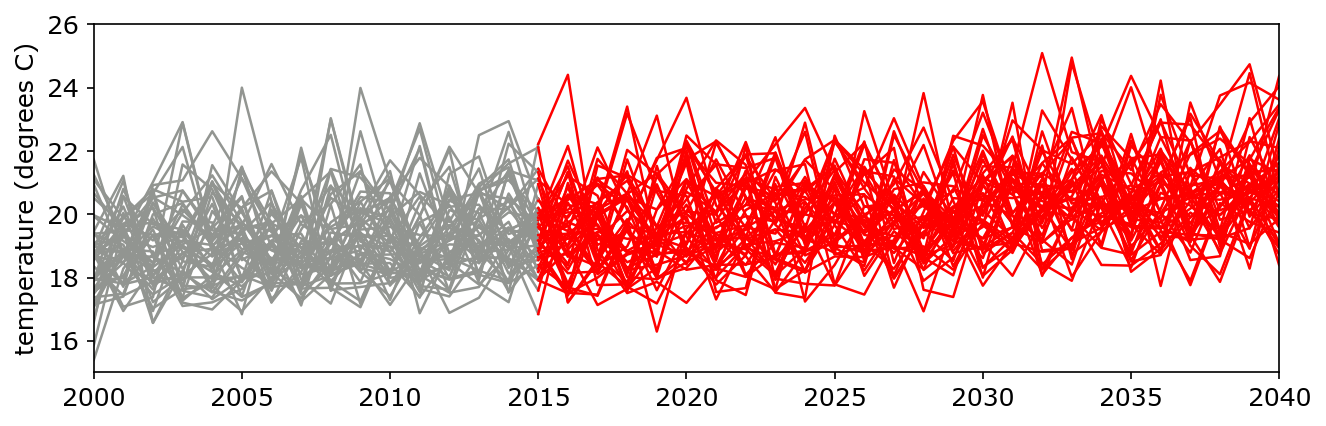

In [195]:
sspcols = ['blue','green','orange','red']

# for issp in range(4):

ilatsel = 13
ilonsel = 25

summersel = AllData.alloutput[3][:,:,ilatsel,ilonsel]-273

maxes = np.zeros(summersel.shape)

for i in range(summersel.shape[0]):
    currentmax = np.max(summersel[i,0:50])
    # print(currentmax)
    for j in range(summersel.shape[1]-50):
        maxcheck = summersel[i,j+50]>currentmax
        if maxcheck:
            maxes[i,j+50] = 1.
            currentmax = summersel[i,j+50]

maxes[maxes==0] = np.nan

plt.figure(figsize=(9,3))

# plt.plot(np.arange(timerange[0],2016),summersel[0,:116],color='xkcd:grey',linewidth=1.2,label='hist')
# plt.scatter(np.arange(timerange[0],2016),maxes[0,:116]*summersel[0,:116],color='xkcd:maroon')

# plt.plot(np.arange(2015,timerange[-1]+1),summersel[0,115:],color=sspcols[3],label=ssplist[issp],linewidth=1.2)
# plt.scatter(np.arange(2015,timerange[-1]+1),maxes[0,115:]*summersel[0,115:],color='xkcd:maroon')

# plt.plot(np.arange(timerange[0],2016),summersel[1,:116],color='xkcd:grey',linewidth=1.2)
# plt.scatter(np.arange(timerange[0],2016),maxes[1,:116]*summersel[1,:116],color='xkcd:maroon')

# plt.plot(np.arange(2015,timerange[-1]+1),summersel[1,115:],color=sspcols[3],linewidth=1.2)
# plt.scatter(np.arange(2015,timerange[-1]+1),maxes[1,115:]*summersel[1,115:],color='xkcd:maroon')

for mem in range(50):

    plt.plot(np.arange(timerange[0],2016),summersel[mem,:116],color='xkcd:grey',linewidth=1.2)
    # plt.scatter(np.arange(timerange[0],2016),maxes[mem,:116]*summersel[mem,:116],color='xkcd:maroon')

    plt.plot(np.arange(2015,timerange[-1]+1),summersel[mem,115:],color=sspcols[3],linewidth=1.2)
    # plt.scatter(np.arange(2015,timerange[-1]+1),maxes[mem,115:]*summersel[mem,115:],color='xkcd:maroon')

# plt.title('summertime average temperature for lon = ' + str(lonsel+5)+'E, lat = '+ str(-1*(latsel+5))+ 'S' )
plt.ylabel('temperature (degrees C)')
plt.xlim(1900,2100)
plt.xlim(2000,2040)
# plt.ylim(10,28)
plt.ylim(15,26)
# plt.legend()

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'record hot summer frequency')

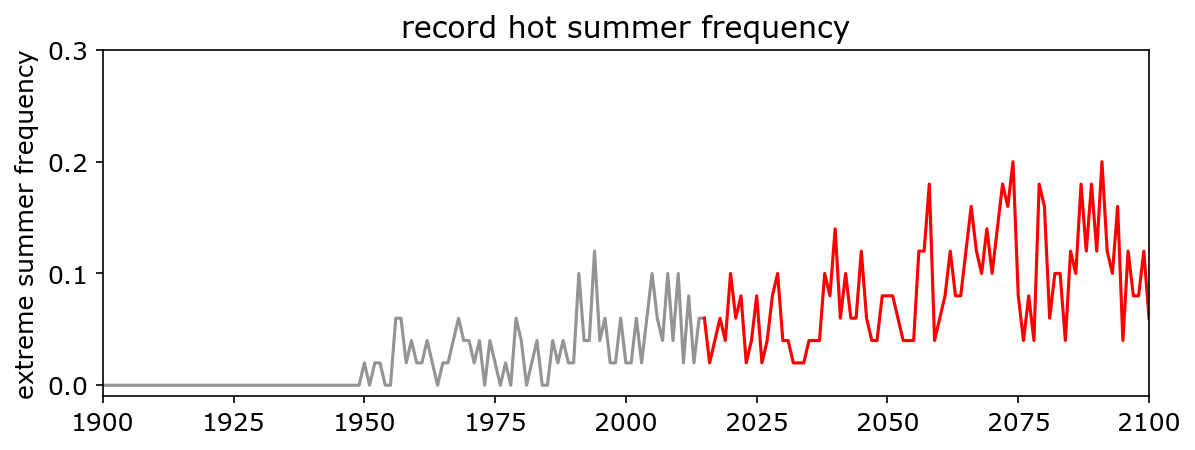

In [170]:
maxesplot = np.copy(maxes)
maxesplot[np.isnan(maxesplot)] = 0

plt.figure(figsize=(9,3))

plt.plot(np.arange(timerange[0],2016),np.nanmean(maxesplot[:,:116],axis=0),color='xkcd:grey')
plt.plot(np.arange(2015,timerange[-1]+1),np.nanmean(maxesplot[:,115:],axis=0),color=sspcols[3])
plt.ylabel('extreme summer frequency')
plt.xlim(1900,2100)
plt.ylim(-0.01,0.3)

plt.title("record hot summer frequency")

In [171]:
stackrun = np.empty((maxes.shape[0],maxes.shape[1]-5+1))

for i in range(maxes.shape[1]-5+1):
    stackloop = np.mean(maxesplot[:,i:i+5],axis=1)
    stackrun[:,i] = np.ceil(stackloop)

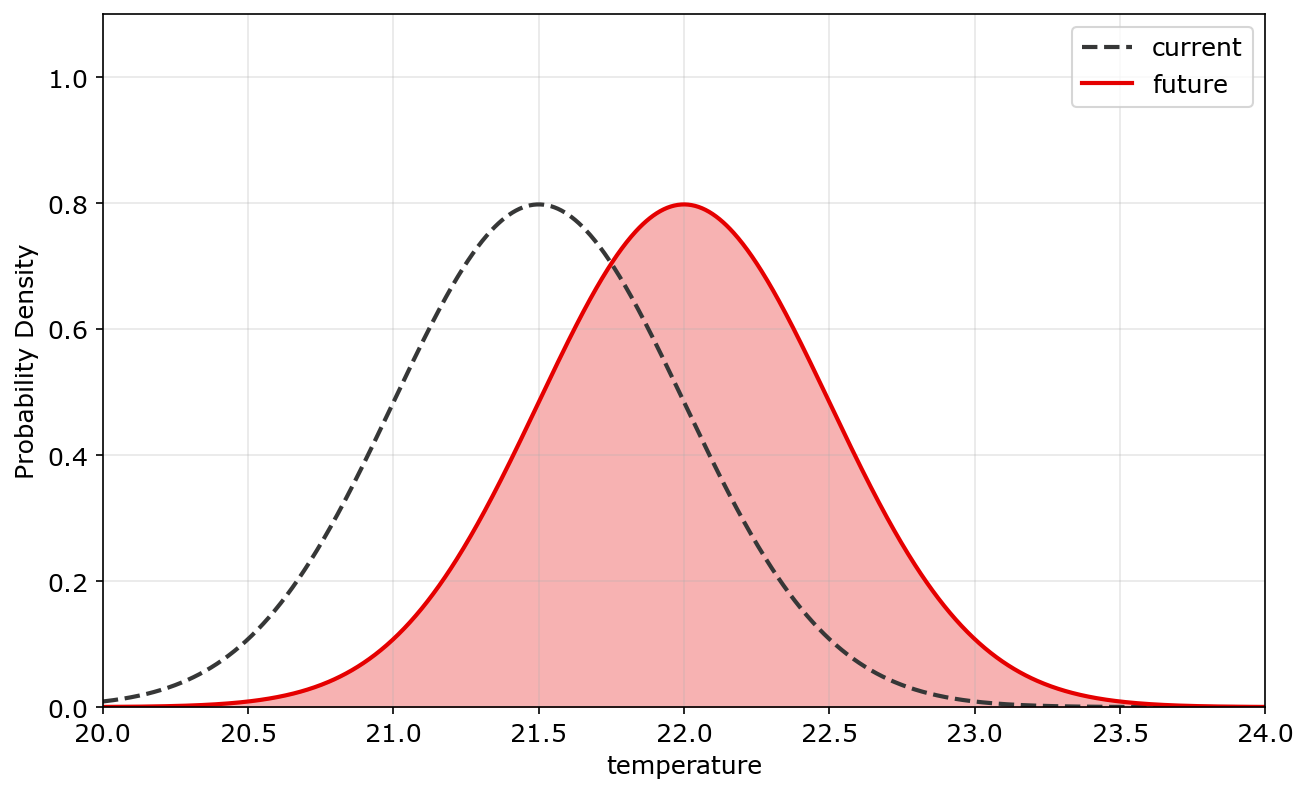

In [200]:
import numpy as np
import matplotlib.pyplot as plt

mean, std = 22, 0.5
x = np.linspace(20, 24, 1000)
y = (1/(std * np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mean)/std)**2)

mean3, std3 = 21.5, 0.5
x3 = np.linspace(20, 24, 1000)
y3 = (1/(std3 * np.sqrt(2*np.pi))) * np.exp(-0.5*((x3-mean3)/std3)**2)

plt.figure(figsize=(10, 6))

plt.plot(x3, y3, 'xkcd:dark gray', linewidth=2, label='current', linestyle='dashed')
plt.plot(x, y, 'xkcd:red', linewidth=2,label='future')
plt.fill_between(x, y, alpha=0.3,color="xkcd:red")
# plt.title(f'Normal Distribution (μ={mean}, σ={std})')
plt.xlabel('temperature')
plt.ylabel('Probability Density')
plt.xlim(20,24)
plt.ylim(0,1.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


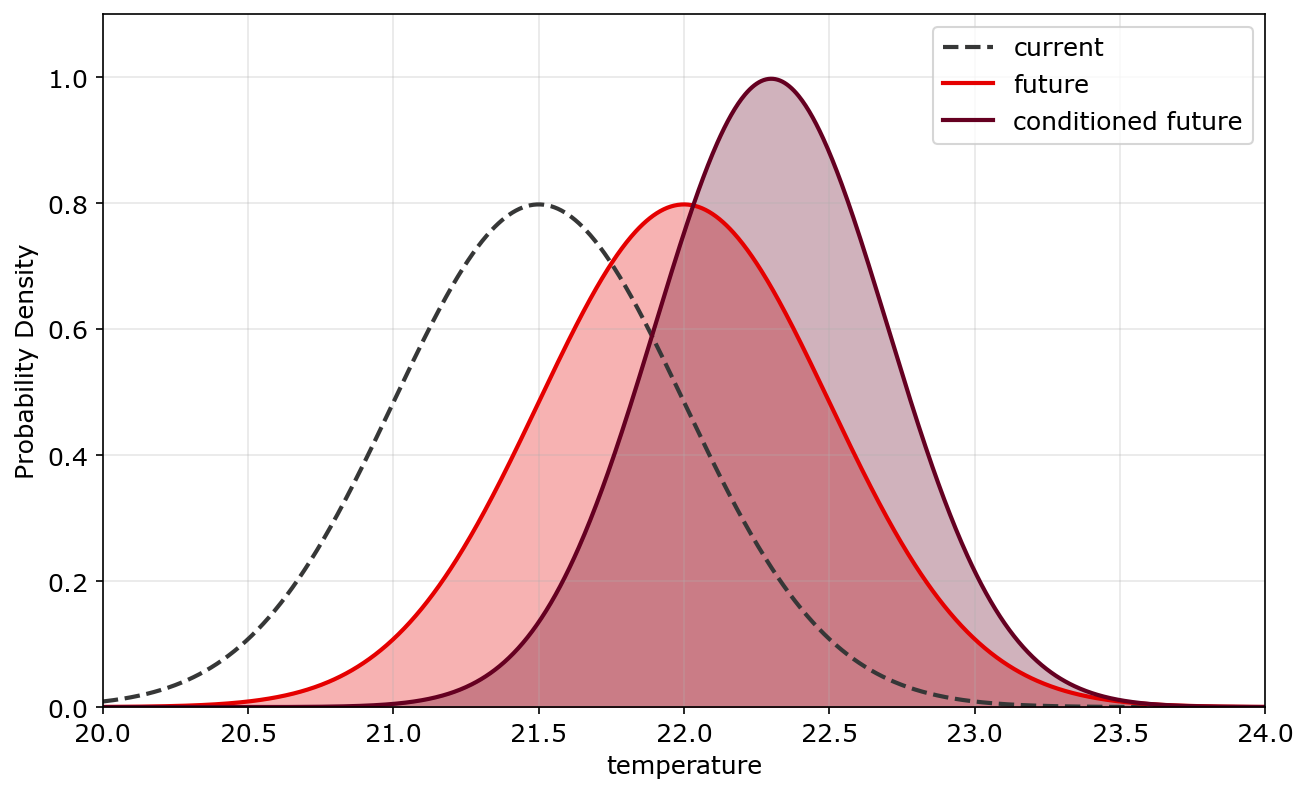

In [201]:
import numpy as np
import matplotlib.pyplot as plt

# First distribution
mean1, std1 = 22, 0.5
x1 = np.linspace(20, 24, 1000)
y1 = (1/(std1 * np.sqrt(2*np.pi))) * np.exp(-0.5*((x1-mean1)/std1)**2)

# Second distribution
mean2, std2 = 22.3, 0.4
x2 = np.linspace(20, 24, 1000)
y2 = (1/(std2 * np.sqrt(2*np.pi))) * np.exp(-0.5*((x2-mean2)/std2)**2)

mean3, std3 = 21.5, 0.5
x3 = np.linspace(20, 24, 1000)
y3 = (1/(std3 * np.sqrt(2*np.pi))) * np.exp(-0.5*((x3-mean3)/std3)**2)

plt.figure(figsize=(10, 6))

# Plot first distribution
plt.plot(x3, y3, 'xkcd:dark gray', linewidth=2, label='current', linestyle='dashed')

plt.plot(x1, y1, 'xkcd:red', linewidth=2, label='future')
plt.fill_between(x1, y1, alpha=0.3, color='xkcd:red')

# Plot second distribution
plt.plot(x2, y2, 'xkcd:maroon', linewidth=2, label='conditioned future')
plt.fill_between(x2, y2, alpha=0.3, color='xkcd:maroon')

# plt.title('Normal Distributions Comparison')
plt.xlabel('temperature')
plt.ylabel('Probability Density')
plt.xlim(20,24)
plt.ylim(0,1.1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

(-0.01, 1.02)

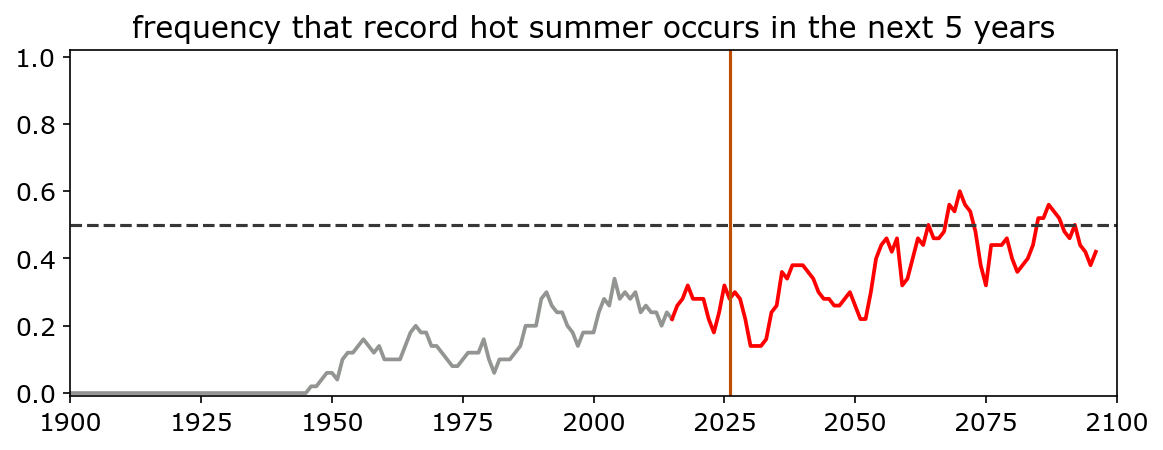

In [172]:
plt.figure(figsize=(9,3))
plt.plot(np.arange(timerange[0],2016),np.mean(stackrun[:,:116],axis=0),color='xkcd:grey',linewidth=1.8)
plt.plot(np.arange(2015,timerange[-1]+2-5),np.mean(stackrun[:,115:],axis=0),color=sspcols[3],linewidth=1.8)
plt.title('frequency that record hot summer occurs in the next 5 years')
plt.hlines(0.5,1900,2100,color='xkcd:dark grey',linestyle='dashed')
plt.vlines(2026,-0.1,1.1,color='xkcd:burnt orange')

plt.xlim(1900,2100)
plt.ylim(-0.01,1.02)

In [118]:
imp.reload(DataHolder)

AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)
alltrain, allval, alltest = AllData.trainvaltest_recordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,latsel,lonsel)

data/MPI_annualmean_126_tos_1900-2100.pkl
data/MPI_annualmean_245_tos_1900-2100.pkl
data/MPI_annualmean_370_tos_1900-2100.pkl
data/MPI_annualmean_585_tos_1900-2100.pkl
baseline for temp records is 0 50
indices of future period are 104 -4
working on 126
working on 245
working on 370
working on 585


In [119]:
alltrain, allval, alltest = AllData.trainvaltest_recordmax_withrecordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,latsel,lonsel)

baseline for temp records is 0 50
indices of future period are 104 -4
working on 126
working on 245
working on 370
working on 585


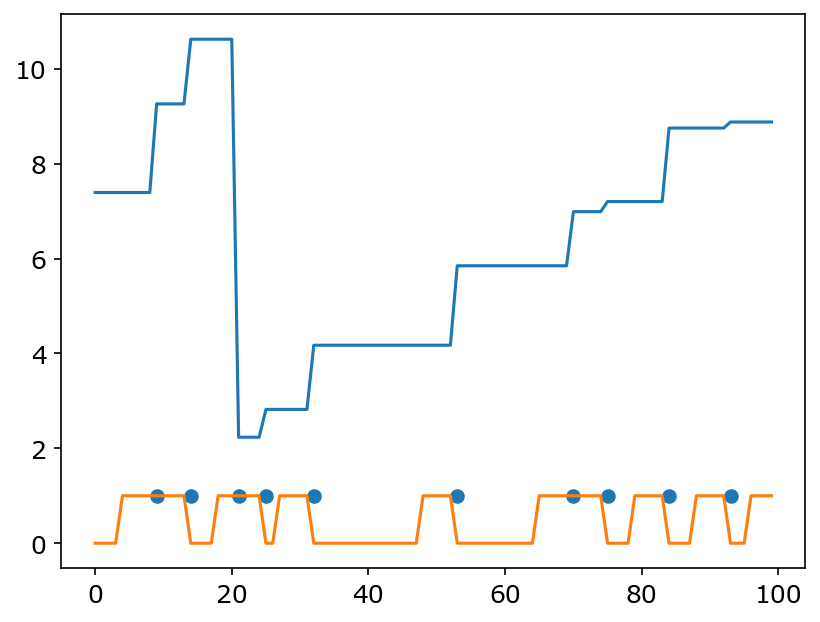

In [120]:
plt.plot(alltrain[2][-100:])

event = np.diff(alltrain[2][-101:].squeeze())
event[event==0] = np.nan
event[~np.isnan(event)] = 1

plt.scatter(np.arange(100),event)
plt.plot(alltrain[-1][-100:])

In [121]:
event.shape

(100,)

In [122]:
encoder = OneHotEncoder(sparse_output=False)

inputssptrain_onehot = encoder.fit_transform(inputssptrain.reshape(-1, 1))
inputssptest_onehot = encoder.fit_transform(inputssptest.reshape(-1, 1))

inputalltrain = np.hstack([inputtrainGMT.numpy(),inputssptrain_onehot])
inputalltest = np.hstack([inputtestGMT.numpy(),inputssptest_onehot])

In [123]:
testfileout = "metrics/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(latsel)+"_lon_"+str(lonsel)+"_testing.json"
fileload = glob.glob(testfileout)

with open(testfileout, "r") as f:
    data = json.load(f)
    bestaccs = np.array(data["test_accuracy"])
    nulls = np.max(np.array(data["test_class_imbalance"]))

filepredictions = "predictions/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(latsel)+"_testing.pkl"

with open(filepredictions,'rb') as f:
    predictions = pickle.load(f)

filetrue = "predictions/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(latsel)+"_truetesting.pkl"

with open(filetrue,'rb') as f:
    truths = pickle.load(f)

avgtestpred = np.mean(predictions,axis=1)
avgtestclass = np.round(avgtestpred)
avgtestconf = np.where(avgtestpred<0.5,1-avgtestpred,avgtestpred)

bs_cnn = np.mean((avgtestpred[ilonsel]-truths[ilonsel])**2)


In [124]:
lr_model = LogisticRegression()
lr_model.fit(inputtrainGMT,outputtrain)

y_pred = lr_model.predict(inputtrainGMT)
y_pred_probs = lr_model.predict_proba(inputtrainGMT)

histtraingmt = inputtrainGMT[inputssptrain==0]
histtestgmt = inputtestGMT[inputssptest==0]

# meanpredhistgmtonly = meanpredgmtonly[inputssptest==0]

outputtrainhist = outputtrain[inputssptrain==0]
outputtesthist = outputtest[inputssptest==0]

avgtestpredhist = avgtestpred[ilonsel,inputssptest==0]

y_predprobs_lr = []
inputgmtssps = []

outputcnngmtonly = []
outputcnn = []
outputallssp = []

inputtrainsspall = []
outputtrainsspall = []

ssplabels = []
ssplabelhist = inputssptest[inputssptest==0]

for i in range(1,5):

    inputtraingmtssp = inputtrainGMT[inputssptrain==i]
    allinputtraingmt = np.concatenate((histtraingmt,inputtraingmtssp),axis=0)

    outputssptrain = outputtrain[inputssptrain==i]
    alloutputtrain = np.concatenate((outputtrainhist,outputssptrain),axis=0)

    inputtestgmtssp = inputtestGMT[inputssptest==i]
    allinputtestgmt = np.concatenate((histtestgmt,inputtestgmtssp),axis=0)

    outputssptest = outputtest[inputssptest==i]
    alloutputtest = np.concatenate((outputtesthist,outputssptest),axis=0)

    # meanpredsspgmtonly = meanpredgmtonly[inputssptest==i]
    # allmeanpredgmtonly = np.concatenate((meanpredhistgmtonly,meanpredsspgmtonly),axis=0)

    meantestpredssp = avgtestpred[ilonsel,inputssptest==i]
    allmeantestpred = np.concatenate((avgtestpredhist,meantestpredssp),axis=0)

    ssplabelssp = inputssptest[inputssptest==i]
    ssplabelsall = np.concatenate((ssplabelhist,ssplabelssp),axis=0)

    # outputtruessp = outputtrain[inputssptrain==i]
    # alloutputtruessp = np.concatenate((outputtruehist,outputtruessp),axis=0)    

    lr_model = LogisticRegression()
    lr_model.fit(allinputtraingmt,alloutputtrain)

    y_pred_ssp = lr_model.predict(allinputtestgmt)
    y_predprobs_ssp = lr_model.predict_proba(allinputtestgmt)

    y_predprobs_lr.append(y_predprobs_ssp)
    inputgmtssps.append(allinputtestgmt)
    # outputcnngmtonly.append(allmeanpredgmtonly)
    outputallssp.append(alloutputtest)
    outputcnn.append(allmeantestpred)
    ssplabels.append(ssplabelsall)

    inputtrainsspall.append(allinputtraingmt)
    outputtrainsspall.append(alloutputtrain)


In [125]:
avgtestpred.shape

(36, 4452)

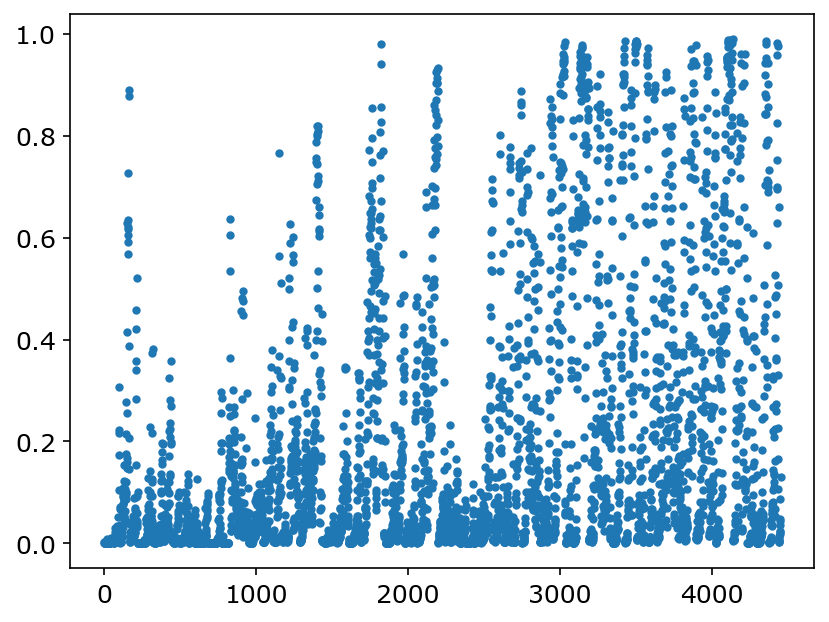

In [126]:
plt.scatter(np.arange(avgtestpred.shape[1]),avgtestpred[ilonsel],marker='.')

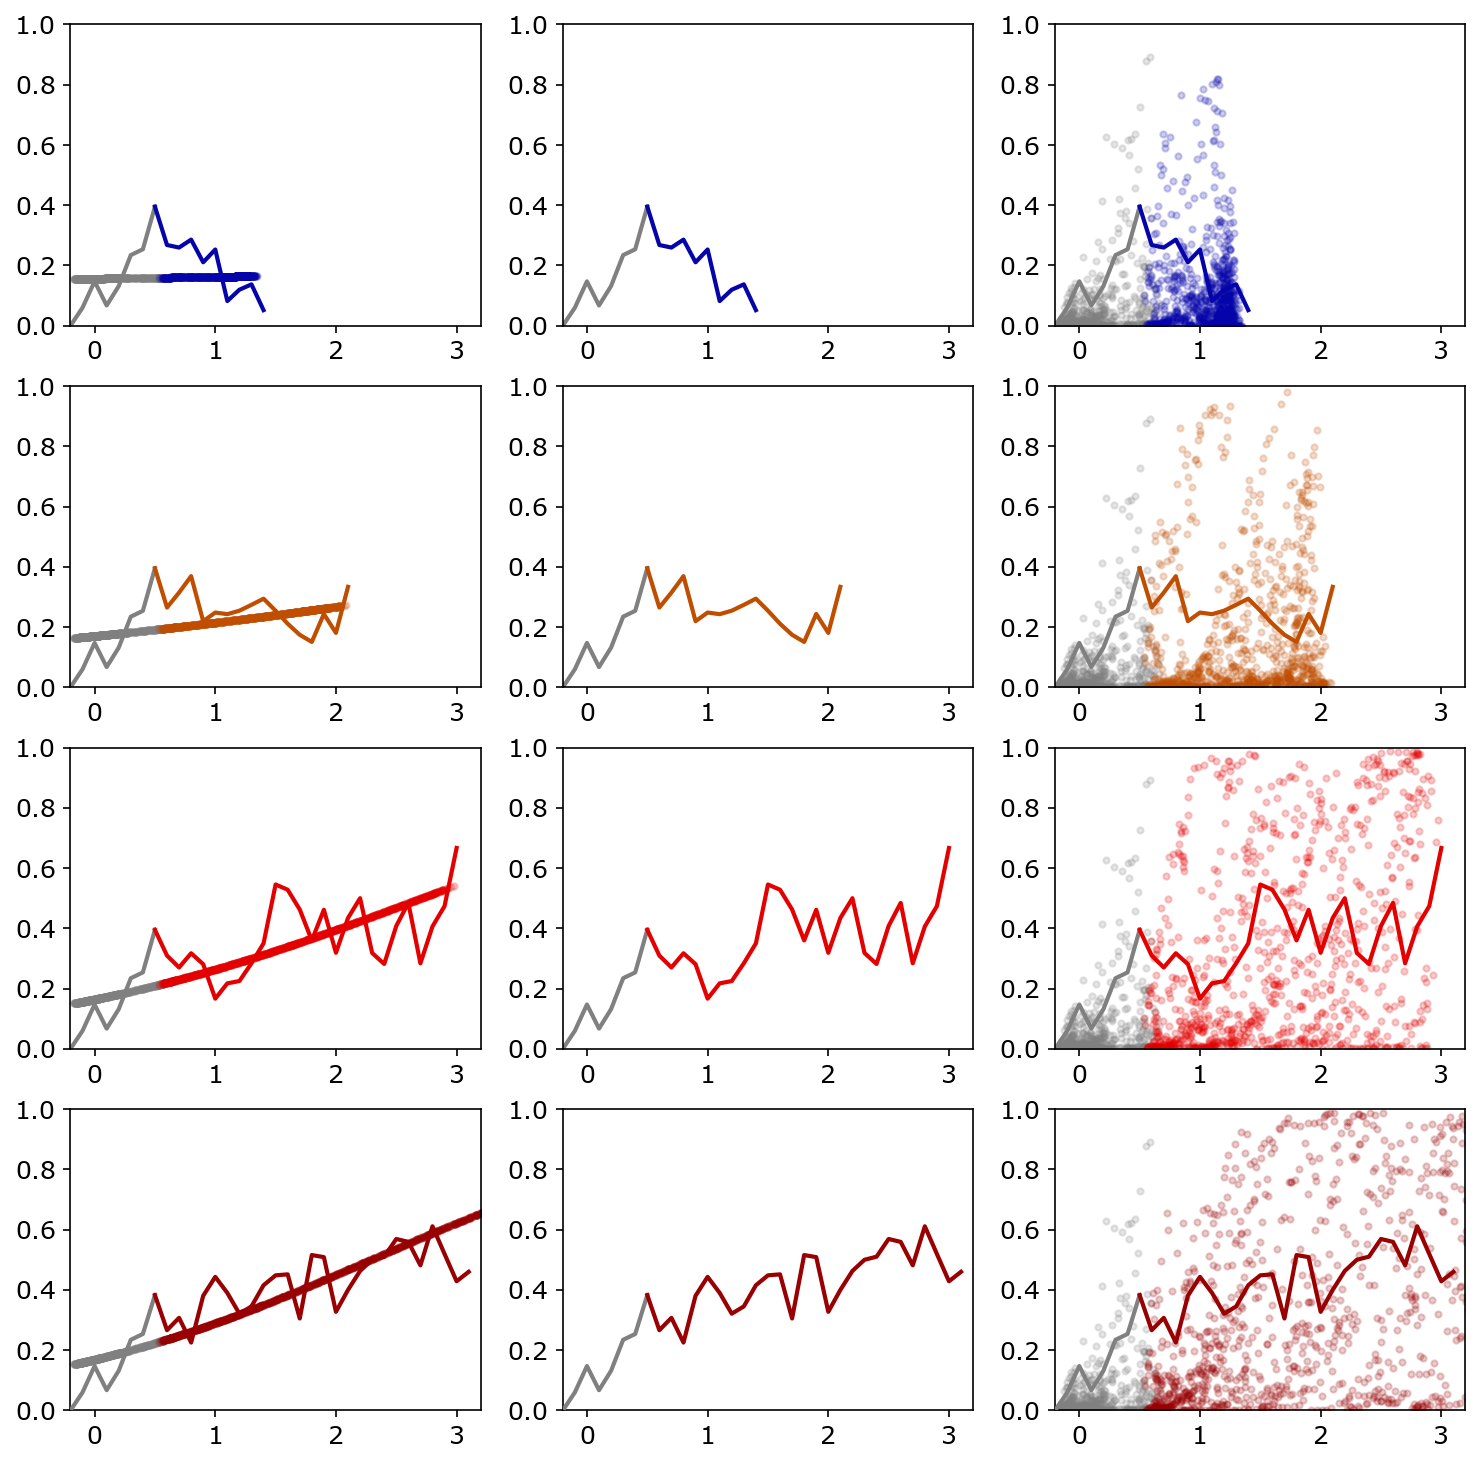

In [127]:
ntrain = 25

plt.figure(figsize=(12,12))

colors=['xkcd:royal blue','xkcd:burnt orange','xkcd:red','xkcd:blood red']

for ind in np.arange(0,4):

    # boosel = inputssptrain.squeeze()==ind
    # nsel = np.sum(1*boosel)
    # nsteps = int(nsel/ntrain)

    # inputgmtssp = inputtrainGMT[boosel].numpy()
    # inputgmtssp = np.reshape(inputgmtssp,(ntrain,nsteps))

    # outputssp = outputtrain[boosel]
    # outputssp = np.reshape(outputssp,(ntrain,nsteps))

    # booseltest = inputssptest.squeeze()==ind
    bins = np.arange(-0.5,3.2,0.1)
    binnedrecordsummer,binsout = binnedprobs(outputtrainsspall[ind],inputtrainsspall[ind].squeeze(),bins)
    sspboo = ssplabels[ind]
    binhistthres = 0.5

    plt.subplot(4,3,3*ind+1)
    plt.plot(binsout[binsout<=binhistthres],binnedrecordsummer[binsout<=binhistthres],color='grey',linewidth=2,zorder=ind)
    plt.plot(binsout[binsout>=(binhistthres-0.1)],binnedrecordsummer[binsout>=(binhistthres-0.1)],color=colors[ind],linewidth=2,zorder=ind,label=ssplist[ind])
    plt.scatter(inputgmtssps[ind][sspboo==0].squeeze(),y_predprobs_lr[ind][sspboo==0,1],color='grey',alpha=0.2,marker='.',zorder=ind-5)
    plt.scatter(inputgmtssps[ind][sspboo==ind+1].squeeze(),y_predprobs_lr[ind][sspboo==ind+1,1],color=colors[ind],alpha=0.2,marker='.',zorder=ind-5)
    plt.xlim(-0.2,3.2)
    plt.ylim(0,1)

    plt.subplot(4,3,3*ind+2,)
    plt.plot(binsout[binsout<=binhistthres],binnedrecordsummer[binsout<=binhistthres],color='grey',linewidth=2,zorder=ind)
    plt.plot(binsout[binsout>=(binhistthres-0.1)],binnedrecordsummer[binsout>=(binhistthres-0.1)],color=colors[ind],linewidth=2,zorder=ind,label=ssplist[ind])
    # plt.scatter(inputgmtssps[ind][sspboo==0].squeeze(),outputcnngmtonly[ind][sspboo==0],marker='.',color='grey',alpha=0.2,zorder=ind-5)
    # plt.scatter(inputgmtssps[ind][sspboo==ind+1].squeeze(),outputcnngmtonly[ind][sspboo==ind+1],marker='.',color=colors[ind],alpha=0.2,zorder=ind-5)
    plt.xlim(-0.2,3.2)
    plt.ylim(0,1)

    plt.subplot(4,3,3*ind+3,)
    plt.plot(binsout[binsout<=binhistthres],binnedrecordsummer[binsout<=binhistthres],color='grey',linewidth=2,zorder=ind)
    plt.plot(binsout[binsout>=(binhistthres-0.1)],binnedrecordsummer[binsout>=(binhistthres-0.1)],color=colors[ind],linewidth=2,zorder=ind,label=ssplist[ind])
    plt.scatter(inputgmtssps[ind][sspboo==0].squeeze(),outputcnn[ind][sspboo==0],marker='.',color='grey',alpha=0.2,zorder=ind-5)
    plt.scatter(inputgmtssps[ind][sspboo==ind+1].squeeze(),outputcnn[ind][sspboo==ind+1],marker='.',color=colors[ind],alpha=0.2,zorder=ind-5)
    plt.xlim(-0.2,3.2)
    plt.ylim(0,1)

    # plt.subplot(4,4,4*ind+4,)
    # plt.scatter(inputtestGMT[booseltest].squeeze(),y_pred_probs[booseltest,1],color=colors[ind],marker='.',zorder=ind)
    # plt.scatter(inputtestGMT[booseltest].squeeze(),np.mean(outputpredgmtonly,axis=0)[booseltest],marker='.',color=colors[ind],alpha=0.2,zorder=ind-5)
    # plt.xlim(-0.2,3.2)
    # plt.ylim(0,1)

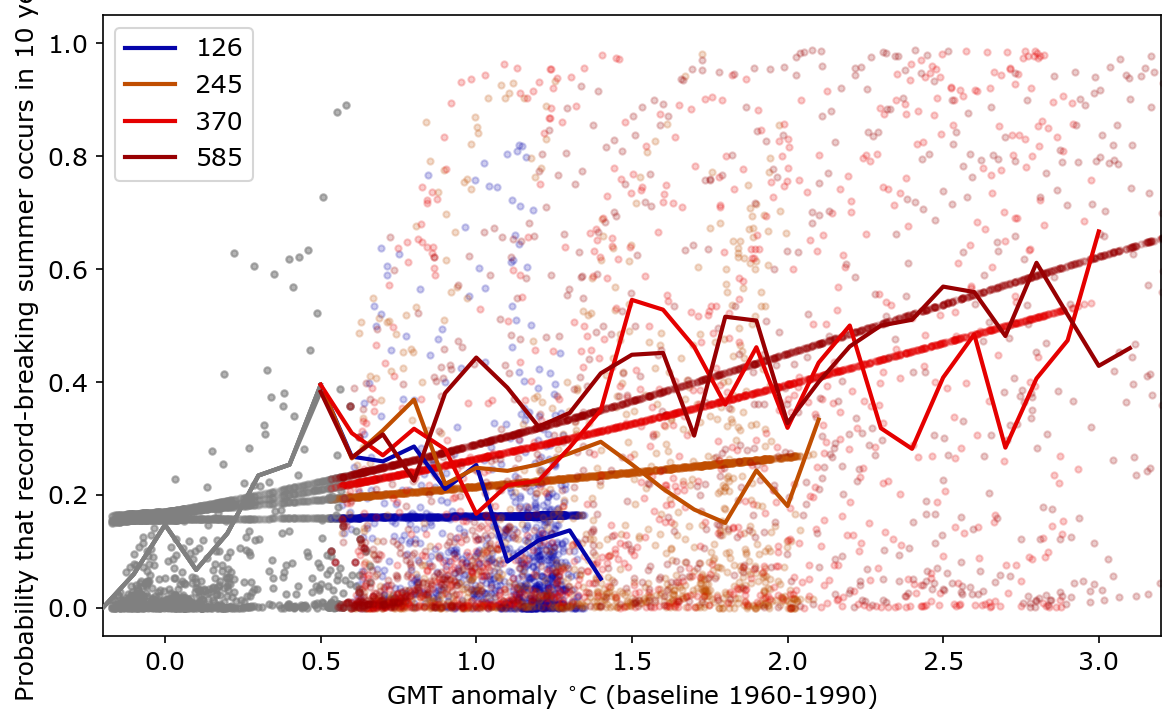

In [128]:
plt.figure(figsize=(8,5))

# sspplotlist = ['Hist']+ssplist
# bins = np.arange(-0.2,3.1,0.1)

for ind,issp in enumerate(np.arange(0,4)):

    bins = np.arange(-0.5,3.2,0.1)
    binnedrecordsummer,binsout = binnedprobs(outputtrainsspall[ind],inputtrainsspall[ind].squeeze(),bins)
    sspboo = ssplabels[ind]
    binhistthres = 0.5

    plt.plot(binsout[binsout<=binhistthres],binnedrecordsummer[binsout<=binhistthres],color='grey',linewidth=2,zorder=ind)
    plt.plot(binsout[binsout>=(binhistthres-0.1)],binnedrecordsummer[binsout>=(binhistthres-0.1)],color=colors[ind],linewidth=2,zorder=ind,label=ssplist[ind])
    plt.scatter(inputgmtssps[ind][sspboo==0].squeeze(),y_predprobs_lr[ind][sspboo==0,1],color='grey',alpha=0.2,marker='.',zorder=ind-5)
    plt.scatter(inputgmtssps[ind][sspboo==ind+1].squeeze(),y_predprobs_lr[ind][sspboo==ind+1,1],color=colors[ind],alpha=0.2,marker='.',zorder=ind-5)

    # plt.scatter(inputgmtssps[ind][sspboo==0].squeeze(),outputcnngmtonly[ind][sspboo==0],marker='.',color='grey',alpha=0.2,zorder=ind-5)
    # plt.scatter(inputgmtssps[ind][sspboo==ind+1].squeeze(),outputcnngmtonly[ind][sspboo==ind+1],marker='.',color=colors[ind],alpha=0.2,zorder=ind-5)

    plt.scatter(inputgmtssps[ind][sspboo==0].squeeze(),outputcnn[ind][sspboo==0],marker='.',color='grey',alpha=0.2,zorder=ind-5)
    plt.scatter(inputgmtssps[ind][sspboo==ind+1].squeeze(),outputcnn[ind][sspboo==ind+1],marker='.',color=colors[ind],alpha=0.2,zorder=ind-5)
    plt.xlim(-0.2,3.2)
    plt.ylim(0,1)


# plt.hlines(0.5,-0.2,3,color='black',linestyle='dashed')
plt.ylim(-0.05,1.05)
plt.xlim(-0.2,3.2)
plt.xlabel("GMT anomaly $^{\circ}$C (baseline 1960-1990)")
plt.ylabel("Probability that record-breaking summer occurs in 10 years")
plt.legend()

plt.tight_layout()

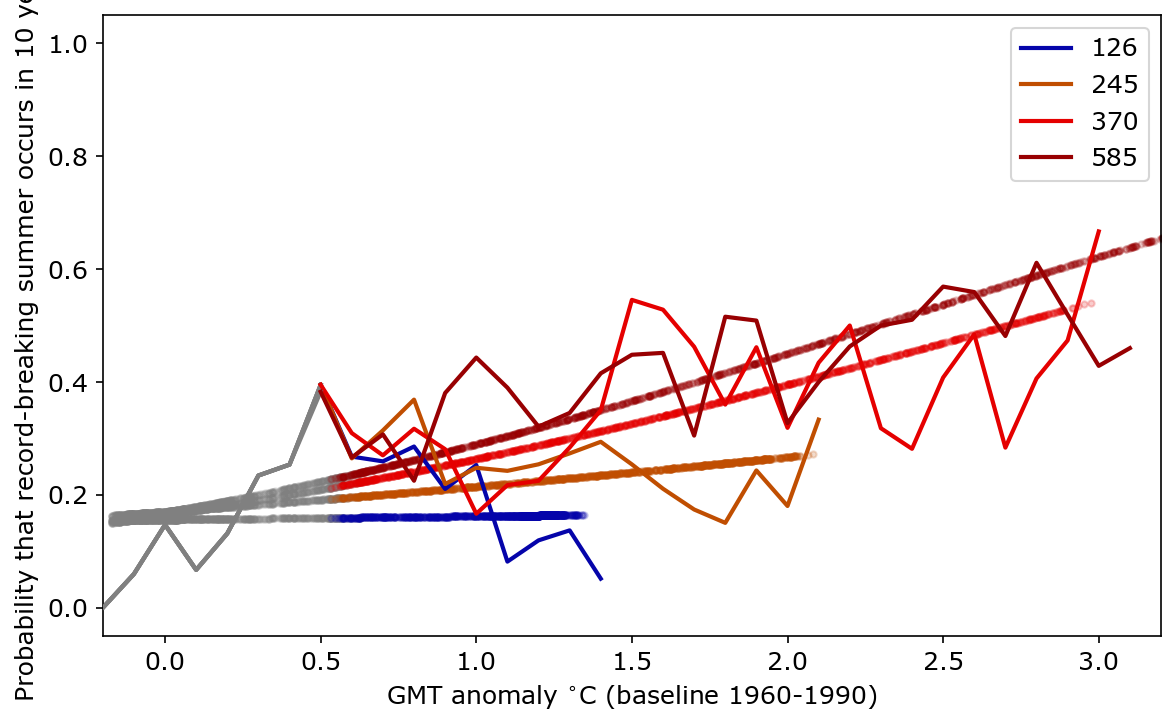

In [129]:
plt.figure(figsize=(8,5))

# sspplotlist = ['Hist']+ssplist
# bins = np.arange(-0.2,3.1,0.1)

for ind,issp in enumerate(np.arange(0,4)):

    bins = np.arange(-0.5,3.2,0.1)
    binnedrecordsummer,binsout = binnedprobs(outputtrainsspall[ind],inputtrainsspall[ind].squeeze(),bins)
    sspboo = ssplabels[ind]
    binhistthres = 0.5

    plt.plot(binsout[binsout<=binhistthres],binnedrecordsummer[binsout<=binhistthres],color='grey',linewidth=2,zorder=ind)
    plt.plot(binsout[binsout>=(binhistthres-0.1)],binnedrecordsummer[binsout>=(binhistthres-0.1)],color=colors[ind],linewidth=2,zorder=ind,label=ssplist[ind])
    plt.scatter(inputgmtssps[ind][sspboo==0].squeeze(),y_predprobs_lr[ind][sspboo==0,1],color='grey',alpha=0.2,marker='.',zorder=ind-5)
    plt.scatter(inputgmtssps[ind][sspboo==ind+1].squeeze(),y_predprobs_lr[ind][sspboo==ind+1,1],color=colors[ind],alpha=0.2,marker='.',zorder=ind-5)

    # plt.scatter(inputgmtssps[ind][sspboo==0].squeeze(),outputcnngmtonly[ind][sspboo==0],marker='.',color='grey',alpha=0.2,zorder=ind-5)
    # # plt.scatter(inputgmtssps[ind][sspboo==ind+1].squeeze(),outputcnngmtonly[ind][sspboo==ind+1],marker='.',color=colors[ind],alpha=0.2,zorder=ind-5)

    # plt.scatter(inputgmtssps[ind][sspboo==0].squeeze(),outputcnn[ind][sspboo==0],marker='.',color='grey',alpha=0.2,zorder=ind-5)
    # plt.scatter(inputgmtssps[ind][sspboo==ind+1].squeeze(),outputcnn[ind][sspboo==ind+1],marker='.',color=colors[ind],alpha=0.2,zorder=ind-5)
    plt.xlim(-0.2,3.2)
    plt.ylim(0,1)


# plt.hlines(0.5,-0.2,3,color='black',linestyle='dashed')
plt.ylim(-0.05,1.05)
plt.xlim(-0.2,3.2)
plt.xlabel("GMT anomaly $^{\circ}$C (baseline 1960-1990)")
plt.ylabel("Probability that record-breaking summer occurs in 10 years")
plt.legend()

plt.tight_layout()

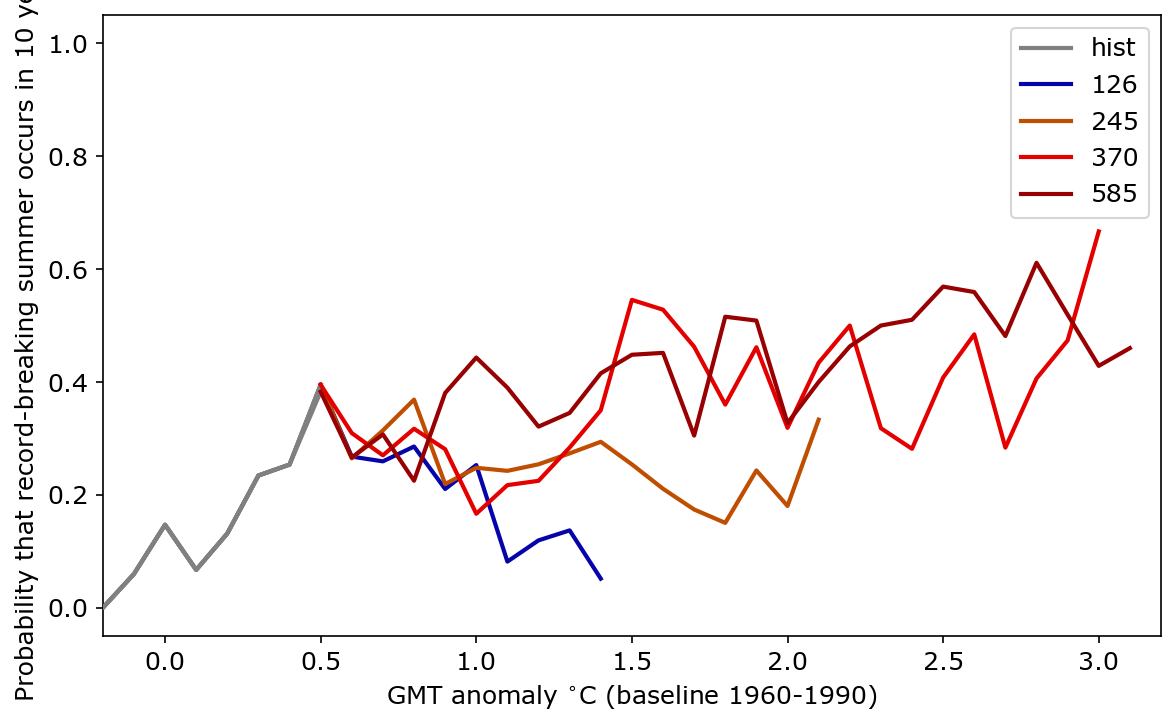

In [130]:
plt.figure(figsize=(8,5))

# sspplotlist = ['Hist']+ssplist
# bins = np.arange(-0.2,3.1,0.1)

for ind,issp in enumerate(np.arange(0,4)):

    bins = np.arange(-0.5,3.2,0.1)
    binnedrecordsummer,binsout = binnedprobs(outputtrainsspall[ind],inputtrainsspall[ind].squeeze(),bins)
    sspboo = ssplabels[ind]
    binhistthres = 0.5

    if ind == 0:
        plt.plot(binsout[binsout<=binhistthres],binnedrecordsummer[binsout<=binhistthres],color='grey',linewidth=2,zorder=ind,label='hist')
    else:
        plt.plot(binsout[binsout<=binhistthres],binnedrecordsummer[binsout<=binhistthres],color='grey',linewidth=2,zorder=ind)
    plt.plot(binsout[binsout>=(binhistthres-0.1)],binnedrecordsummer[binsout>=(binhistthres-0.1)],color=colors[ind],linewidth=2,zorder=ind,label=ssplist[ind])
    # plt.scatter(inputgmtssps[ind][sspboo==0].squeeze(),y_predprobs_lr[ind][sspboo==0,1],color='grey',alpha=0.2,marker='.',zorder=ind-5)
    # plt.scatter(inputgmtssps[ind][sspboo==ind+1].squeeze(),y_predprobs_lr[ind][sspboo==ind+1,1],color=colors[ind],alpha=0.2,marker='.',zorder=ind-5)

    # plt.scatter(inputgmtssps[ind][sspboo==0].squeeze(),outputcnngmtonly[ind][sspboo==0],marker='.',color='grey',alpha=0.2,zorder=ind-5)
    # # plt.scatter(inputgmtssps[ind][sspboo==ind+1].squeeze(),outputcnngmtonly[ind][sspboo==ind+1],marker='.',color=colors[ind],alpha=0.2,zorder=ind-5)

    # plt.scatter(inputgmtssps[ind][sspboo==0].squeeze(),outputcnn[ind][sspboo==0],marker='.',color='grey',alpha=0.2,zorder=ind-5)
    # plt.scatter(inputgmtssps[ind][sspboo==ind+1].squeeze(),outputcnn[ind][sspboo==ind+1],marker='.',color=colors[ind],alpha=0.2,zorder=ind-5)
    plt.xlim(-0.2,3.2)
    plt.ylim(0,1)


# plt.hlines(0.5,-0.2,3,color='black',linestyle='dashed')
plt.ylim(-0.05,1.05)
plt.xlim(-0.2,3.2)
plt.xlabel("GMT anomaly $^{\circ}$C (baseline 1960-1990)")
plt.ylabel("Probability that record-breaking summer occurs in 10 years")
plt.legend()

plt.tight_layout()

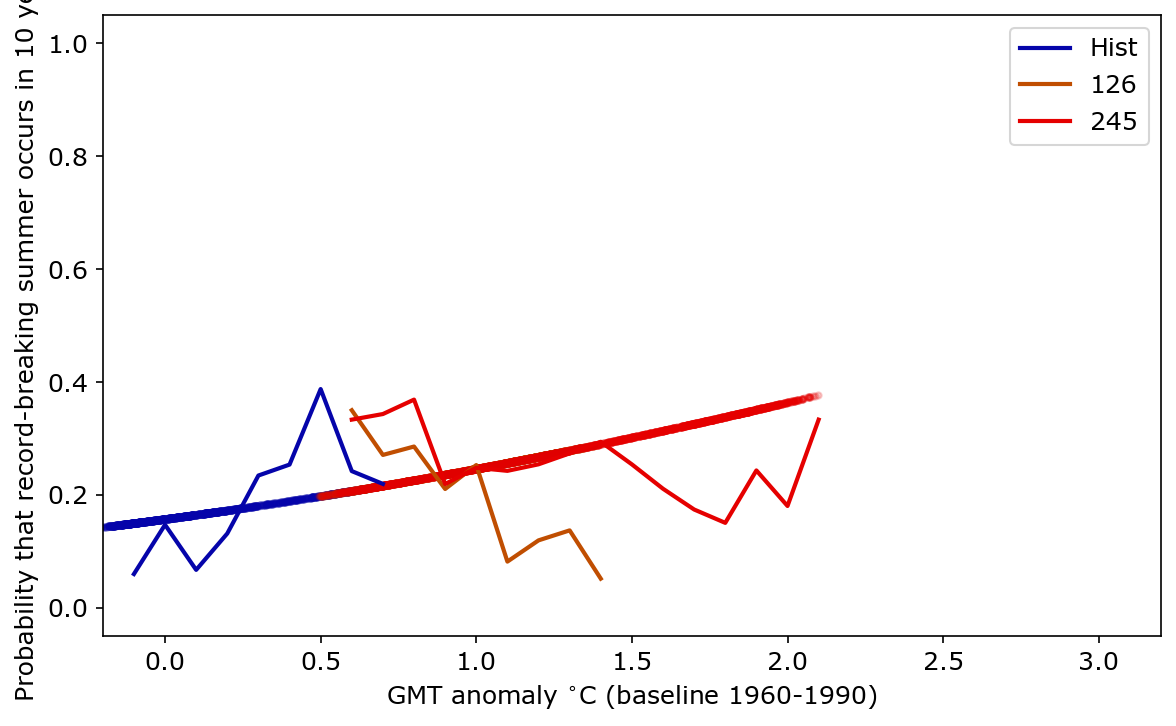

In [131]:
plt.figure(figsize=(8,5))

sspplotlist = ['Hist']+ssplist
bins = np.arange(-0.2,3.1,0.1)

for issp in [0,1,2]:

    boosel = inputssptrain.squeeze()==issp
    nsel = np.sum(1*boosel)
    nsteps = int(nsel/ntrain)

    inputgmtssp = inputtrainGMT[boosel].numpy().squeeze()
    outputssp = outputtrain[boosel]

    # y_pred = lr_model.predict(inputgmtssp[:,np.newaxis])
    # y_pred_probs_loop = lr_model.predict_proba(inputgmtssp[:,np.newaxis])

    # inputgmtsspsq = np.reshape(inputgmtssp,(ntrain,nsteps))
    # outputsspsq = np.reshape(outputssp,(ntrain,nsteps))

    binnedrecordsummer,binsout = binnedprobs(outputssp,inputgmtssp,bins)

    plt.plot(binsout,binnedrecordsummer,color=colors[issp],label=sspplotlist[issp],linewidth=2)
    plt.scatter(inputgmtssp,y_pred_probs[boosel,1],color=colors[issp],alpha=0.2,marker='.',zorder=ind-5)

# plt.hlines(0.5,-0.2,3,color='black',linestyle='dashed')
plt.ylim(-0.05,1.05)
plt.xlim(-0.2,3.2)
plt.xlabel("GMT anomaly $^{\circ}$C (baseline 1960-1990)")
plt.ylabel("Probability that record-breaking summer occurs in 10 years")
plt.legend()

plt.tight_layout()

In [132]:
inputgrab = inputtrainGMT.squeeze().numpy()
inputgrabhist = inputgrab[(inputssptrain==0)]
inputgrabssp585 = inputgrab[inputssptrain==4]

In [133]:
inputhistreshape = np.reshape(inputgrabhist,(25,int(len(inputgrabhist)/25)))
inputssp585reshape = np.reshape(inputgrabssp585,(25,int(len(inputgrabssp585)/25)))

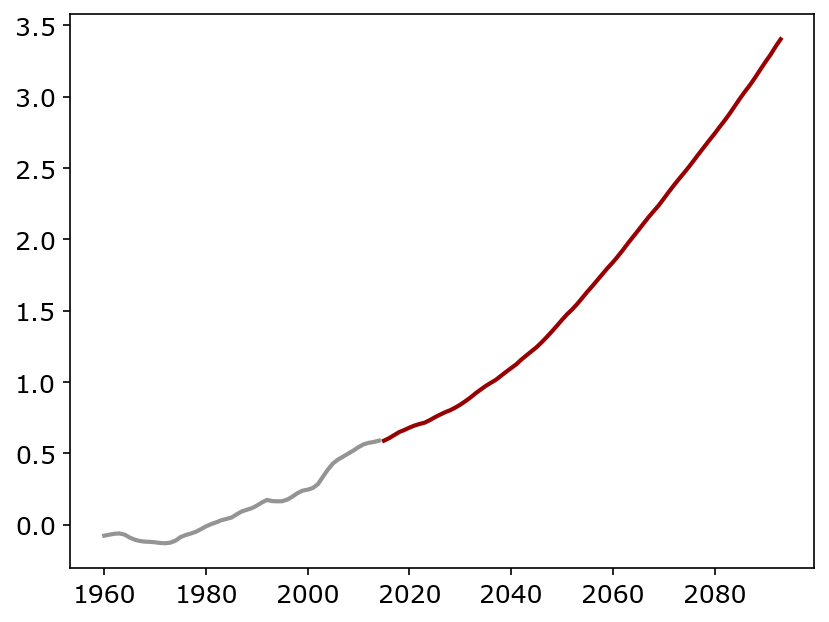

In [134]:
plt.plot(np.arange(1960,2015),np.mean(inputhistreshape,axis=0),color="xkcd:grey",linewidth=2)
plt.plot(np.arange(2015,2094),np.mean(inputssp585reshape,axis=0),color="xkcd:blood red",linewidth=2)
